In [1]:
import numpy as np 
import pandas as pd 
import utils
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker


In [2]:
gama, nessie_groups_gama, sussex_groups_gama, bij = utils.load_group_set_gama()

In [3]:
nessie_groups_gama.columns

Index(['group_id', 'Nfof', 'IterCenRA', 'IterCenDec', 'IterCenZ',
       'IterCenUberID', 'Zfof', 'Rad50', 'Rad100', 'Rad1Sig', 'VelDisp',
       'VelDispErr', 'MassProxy', 'TotFluxProxy', 'BCGUberID', 'BCGRA',
       'BCGDec', 'BCGZ', 'CenRA', 'CenDec', 'TotRmag', 'MassA', 'LumB',
       'MassAfunc', 'LumBfunc', 'GAMARegion'],
      dtype='object')

In [4]:
nessie_groups = nessie_groups_gama[nessie_groups_gama['IterCenZ'] < 0.3]
nessie_groups = nessie_groups_gama[nessie_groups_gama['IterCenRA'] > 40.]

In [5]:
bins = np.linspace(2, 51, 50)

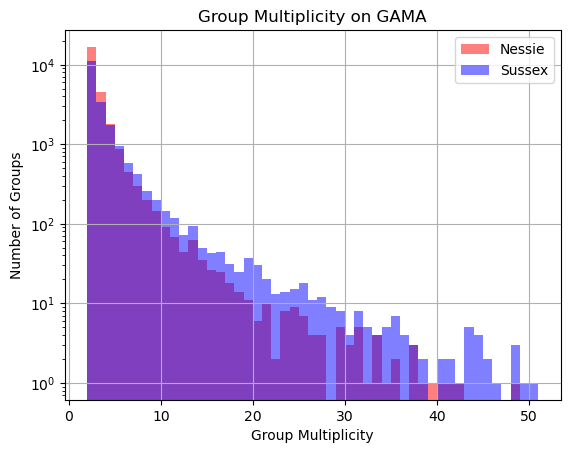

In [6]:
plt.hist(nessie_groups_gama['Nfof'], bins=bins, alpha=0.5, label='Nessie', color='red', log= True)
plt.hist(sussex_groups_gama['multiplicity'], bins=bins, alpha=0.5, label='Sussex', color='blue', log= True)
#plt.hist(sharks_groups['n_group_fof'], bins=bins, alpha=0.5, label='Sussex', color='blue', log= True)
# n_group_fof

plt.legend()
plt.xlabel('Group Multiplicity')
plt.ylabel('Number of Groups')
plt.grid()
plt.title('Group Multiplicity on GAMA')
plt.savefig('../../plots/gama_multiplicity_histogram.png')

In [7]:
sharks, sharks_groups, nessie_groups_sharks, sussex_groups_sharks = utils.load_group_set_sharks_like_gama()

In [8]:
nessie_groups.columns

Index(['group_id', 'Nfof', 'IterCenRA', 'IterCenDec', 'IterCenZ',
       'IterCenUberID', 'Zfof', 'Rad50', 'Rad100', 'Rad1Sig', 'VelDisp',
       'VelDispErr', 'MassProxy', 'TotFluxProxy', 'BCGUberID', 'BCGRA',
       'BCGDec', 'BCGZ', 'CenRA', 'CenDec', 'TotRmag', 'MassA', 'LumB',
       'MassAfunc', 'LumBfunc', 'GAMARegion'],
      dtype='object')

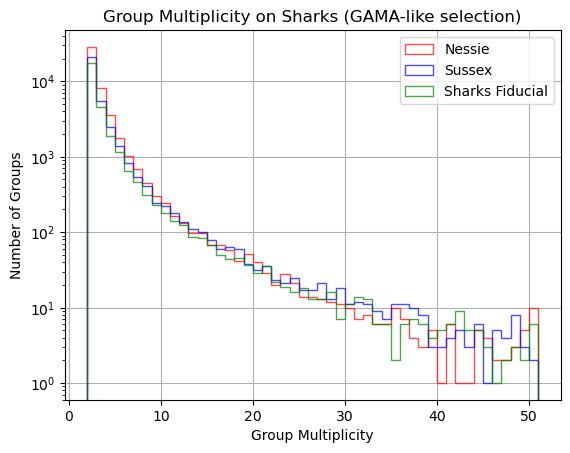

In [20]:
bins = np.linspace(2, 51, 50)
plt.hist(nessie_groups_sharks['nessie_multiplicity'], bins=bins, alpha=0.7, label='Nessie', color='red', log= True, histtype='step')
plt.hist(sussex_groups_sharks['sussex_multiplicity'], bins=bins, alpha=0.7, label='Sussex', color='blue', log= True, histtype='step')
plt.hist(sharks_groups['n_group_fof'], bins=bins, alpha=0.7, label='Sharks Fiducial', color='green', log= True, histtype='step')
# n_group_fof

plt.legend()
plt.xlabel('Group Multiplicity')
plt.ylabel('Number of Groups')
plt.grid()
plt.title('Group Multiplicity on Sharks (GAMA-like selection)')
plt.savefig('../../plots/sharks_gama_multiplicity_histogram.png')

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM


def wrap_ra_diff(ra, ra0):
    """Smallest signed RA difference in degrees, handling wrap-around."""
    return (ra - ra0 + 180.0) % 360.0 - 180.0


# ---------------------------------------------------------------------------
# Drawing helpers — wedge opens rightward:
#   x = r · cos θ   (radial / distance axis, runs left→right)
#   y = r · sin θ   (angular / RA axis, runs bottom→top)
# θ is measured from the region centre; θ_min < 0, θ_max > 0.
# ---------------------------------------------------------------------------

def _wedge_xy_limits(theta_min, theta_max, r_max, pad=0.04):
    x0, x1 = 0.0, r_max
    y0 = r_max * np.sin(theta_min)
    y1 = r_max * np.sin(theta_max)
    dx, dy = x1 - x0, y1 - y0
    return x0 - pad * dx, x1 + pad * dx, y0 - pad * dy, y1 + pad * dy


def _draw_wedge_frame(ax, theta_min, theta_max, r_max, n=400,
                      color="0.25", lw=0.9):
    for theta in (theta_min, theta_max):
        ax.plot([0, r_max * np.cos(theta)],
                [0, r_max * np.sin(theta)],
                color=color, lw=lw, zorder=1)
    t = np.linspace(theta_min, theta_max, n)
    ax.plot(r_max * np.cos(t), r_max * np.sin(t),
            color=color, lw=lw, zorder=1)


def _draw_arc_gridlines(ax, theta_min, theta_max, r_ticks, n=300,
                         color="0.82", lw=0.4, ls="--"):
    t = np.linspace(theta_min, theta_max, n)
    for r in r_ticks:
        ax.plot(r * np.cos(t), r * np.sin(t),
                color=color, lw=lw, linestyle=ls, zorder=0)


def _draw_radial_gridlines(ax, theta_ticks, r_max,
                            color="0.82", lw=0.4, ls="--"):
    for theta in theta_ticks:
        ax.plot([0, r_max * np.cos(theta)],
                [0, r_max * np.sin(theta)],
                color=color, lw=lw, linestyle=ls, zorder=0)


def _add_ra_labels(ax, ra_vals, theta_ticks, r_max, fontsize=9, pad=1.05):
    """RA labels just outside the outer arc."""
    for ra, theta in zip(ra_vals, theta_ticks):
        x = pad * r_max * np.cos(theta)
        y = pad * r_max * np.sin(theta)
        va = "center"
        if   np.sin(theta) >  0.1: va = "bottom"
        elif np.sin(theta) < -0.1: va = "top"
        ax.text(x, y, f"{ra:.0f}°", ha="left", va=va,
                fontsize=fontsize, color="0.35")


def _add_distance_labels(ax, r_ticks, theta_bottom, use_redshift_y,
                          fontsize=8, pad=1.03):
    """Distance / redshift labels just outside the lower radial boundary."""
    for r in r_ticks:
        x = pad * r * np.cos(theta_bottom)
        y = pad * r * np.sin(theta_bottom)
        label = f"z={r:.2f}" if use_redshift_y else f"{r:.0f}"
        ax.text(x, y, label, ha="center", va="top",
                fontsize=fontsize, color="0.45")


def _dress_wedge_ax(ax, theta_min, theta_max, r_max,
                    ra_min, ra_max, ra0, dec0,
                    use_redshift_y=False, n_r_ticks=5, n_ra_ticks=9):
    _draw_wedge_frame(ax, theta_min, theta_max, r_max)

    r_ticks = np.linspace(0, r_max, n_r_ticks + 1)[1:]
    _draw_arc_gridlines(ax, theta_min, theta_max, r_ticks)
    _add_distance_labels(ax, r_ticks, theta_min, use_redshift_y)

    dec0_rad    = np.deg2rad(dec0)
    ra_vals     = np.linspace(ra_min, ra_max, n_ra_ticks)
    theta_ticks = np.deg2rad(wrap_ra_diff(ra_vals, ra0)) * np.cos(dec0_rad)
    _draw_radial_gridlines(ax, theta_ticks, r_max)
    _add_ra_labels(ax, ra_vals, theta_ticks, r_max)

    x0, x1, y0, y1 = _wedge_xy_limits(theta_min, theta_max, r_max)
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_aspect("equal")
    ax.set_axis_off()


# ---------------------------------------------------------------------------
# Public API
# ---------------------------------------------------------------------------

def prepare_single_region_catalog(
    df,
    ra_min, ra_max, dec_min, dec_max,
    ra_col="RAcen", dec_col="Deccen", z_col="Z",
    cosmo=None,
):
    """
    Filter a catalogue to a single rectangular RA/Dec region and compute
    the Cartesian wedge coordinates.

    Parameters
    ----------
    df                      : input DataFrame
    ra_min, ra_max          : RA bounds in degrees
    dec_min, dec_max        : Dec bounds in degrees
    ra_col, dec_col, z_col  : column names
    cosmo                   : astropy cosmology (default FlatLambdaCDM H0=70, Om0=0.3)

    Returns
    -------
    plot_df   : filtered DataFrame with added columns:
                  Dc_Mpc, theta_rad
    region    : dict with region geometry (ra0, dec0, theta_min, theta_max)
    """
    if cosmo is None:
        cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

    plot_df = df[[ra_col, dec_col, z_col]].copy()
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()
    plot_df = plot_df[plot_df[z_col] > 0].copy()

    # Filter to region
    ra  = plot_df[ra_col].values % 360.0
    dec = plot_df[dec_col].values
    mask = (ra >= ra_min) & (ra <= ra_max) & (dec >= dec_min) & (dec <= dec_max)
    plot_df = plot_df[mask].copy()

    ra0  = 0.5 * (ra_min + ra_max)
    dec0 = 0.5 * (dec_min + dec_max)

    plot_df["Dc_Mpc"] = cosmo.comoving_distance(plot_df[z_col].values).value

    dec0_rad = np.deg2rad(dec0)
    delta_ra_deg = wrap_ra_diff(plot_df[ra_col].values % 360.0, ra0)
    plot_df["theta_rad"] = np.deg2rad(delta_ra_deg) * np.cos(dec0_rad)

    theta_min = np.deg2rad(ra_min - ra0) * np.cos(dec0_rad)
    theta_max = np.deg2rad(ra_max - ra0) * np.cos(dec0_rad)

    region = dict(
        ra0=ra0, dec0=dec0,
        ra_min=ra_min, ra_max=ra_max,
        dec_min=dec_min, dec_max=dec_max,
        theta_min=theta_min, theta_max=theta_max,
    )

    return plot_df, region


def plot_single_region_wedge(
    catalogs,
    column_specs,
    ra_min, ra_max, dec_min, dec_max,
    labels,
    colors,
    markers,
    use_redshift_y=True,
    figsize=(16, 7),
    alpha=0.45,
    size=2.5,
    cosmo=None,
    title=None,
):
    """
    Plot a single wide wedge from one or more overlaid catalogues.

    Parameters
    ----------
    catalogs        : list of DataFrames
    column_specs    : list of dicts [{"ra": "...", "dec": "...", "z": "..."}, ...]
    ra_min, ra_max  : RA extent of the region in degrees (e.g. 150, 230 for ~80°)
    dec_min, dec_max: Dec extent of the region in degrees
    labels          : list of str, one per catalogue
    colors          : list of colour specs
    markers         : list of marker strings
    use_redshift_y  : if True label the radial axis as redshift, else Dc in Mpc
    figsize         : figure size in inches — (width, height)
    alpha, size     : scatter aesthetics
    cosmo           : astropy cosmology object (default FlatLambdaCDM H0=70, Om0=0.3)
    title           : optional figure title string

    Returns
    -------
    fig, ax, prepared_catalogs
    """
    if cosmo is None:
        cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

    # --- prepare all catalogues ----------------------------------------------
    prepared = []
    region   = None
    for df, spec in zip(catalogs, column_specs):
        plot_df, region = prepare_single_region_catalog(
            df,
            ra_min=ra_min, ra_max=ra_max,
            dec_min=dec_min, dec_max=dec_max,
            ra_col=spec["ra"], dec_col=spec["dec"], z_col=spec["z"],
            cosmo=cosmo,
        )
        prepared.append((plot_df, spec))

    # --- radial max ----------------------------------------------------------
    r_max = 0.0
    for plot_df, spec in prepared:
        col = spec["z"] if use_redshift_y else "Dc_Mpc"
        if len(plot_df):
            r_max = max(r_max, plot_df[col].max())
    r_max *= 1.

    theta_min = region["theta_min"]
    theta_max = region["theta_max"]

    # --- figure layout -------------------------------------------------------
    # Margins in figure fractions
    left_frac   = 0.03
    right_frac  = 0.06   # room for RA labels poking past the arc
    top_frac    = 0.06   # room for title
    bottom_frac = 0.10   # room for distance labels + legend

    ax_w_frac = 1.0 - left_frac - right_frac
    ax_h_frac = 1.0 - top_frac - bottom_frac

    fig = plt.figure(figsize=figsize)
    ax  = fig.add_axes([left_frac, bottom_frac, ax_w_frac, ax_h_frac])

    _dress_wedge_ax(
        ax, theta_min, theta_max, r_max,
        ra_min=ra_min, ra_max=ra_max,
        ra0=region["ra0"], dec0=region["dec0"],
        use_redshift_y=use_redshift_y,
    )

    # --- scatter catalogs ----------------------------------------------------
    legend_handles = []
    legend_labels  = []
    for (plot_df, spec), label, color, marker in zip(
            prepared, labels, colors, markers):
        if len(plot_df) == 0:
            continue
        r     = plot_df[spec["z"]].values if use_redshift_y else plot_df["Dc_Mpc"].values
        theta = plot_df["theta_rad"].values
        sc = ax.scatter(
            r * np.cos(theta), r * np.sin(theta),
            s=size, alpha=alpha, c=color, marker=marker,
            rasterized=True, linewidths=0, zorder=3,
        )
        legend_handles.append(sc)
        legend_labels.append(label)


    # --- legend --------------------------------------------------------------
    if legend_handles:
        fig.legend(
            handles=legend_handles, labels=legend_labels,
            loc="lower center",
            bbox_to_anchor=(left_frac + ax_w_frac * 0.5, bottom_frac * 0.55),
            bbox_transform=fig.transFigure,
            ncol=len(legend_labels),
            frameon=False,
            markerscale=2,
            fontsize=9,
        )

    # --- title ---------------------------------------------------------------
    if title is None:
        title = (rf"$\alpha = {ra_min:.1f}^\circ$–${ra_max:.1f}^\circ$,"
                 rf"  $\delta = {dec_min:.1f}^\circ$–${dec_max:.1f}^\circ$")
    fig.suptitle(title, fontsize=10, y=1.0 - top_frac * 0.4)

    return fig, ax, [p for p, _ in prepared]

In [14]:
sharks_groups.columns

Index(['group_id', 'ra_bcg', 'dec_bcg', 'redshift_observed_bcg',
       'mag_abs_r_VST_bcg', 'stellar_mass_bcg', 'log_stellar_mass_bcg',
       'fof_halo_mass', 'log_fof_halo_mass', 'group_L', 'log_group_L',
       'n_group_fof', 'group_stellar_mass', 'log_group_stellar_mass',
       'matched_nessie_id', 'matched_sussex_id', 'nessie_iter_ra',
       'nessie_iter_dec', 'nessie_iter_redshift', 'nessie_iter_idx',
       'nessie_median_redshift', 'nessie_co_dist', 'nessie_r50', 'nessie_r100',
       'nessie_rsigma', 'nessie_multiplicity',
       'nessie_velocity_dispersion_gap', 'nessie_velocity_dispersion_gap_err',
       'nessie_mass_proxy', 'nessie_estimated_mass',
       'nessie_vd_corrected_mass', 'nessie_bcg_idxs', 'nessie_bcg_ras',
       'nessie_bcg_decs', 'nessie_bcg_redshifts', 'nessie_center_of_light_ras',
       'nessie_center_of_light_decs', 'nessie_total_absolute_mag',
       'nessie_flux_proxies', 'sussex_centre_ra', 'sussex_centre_dec',
       'sussex_centre_redshift', 'sus

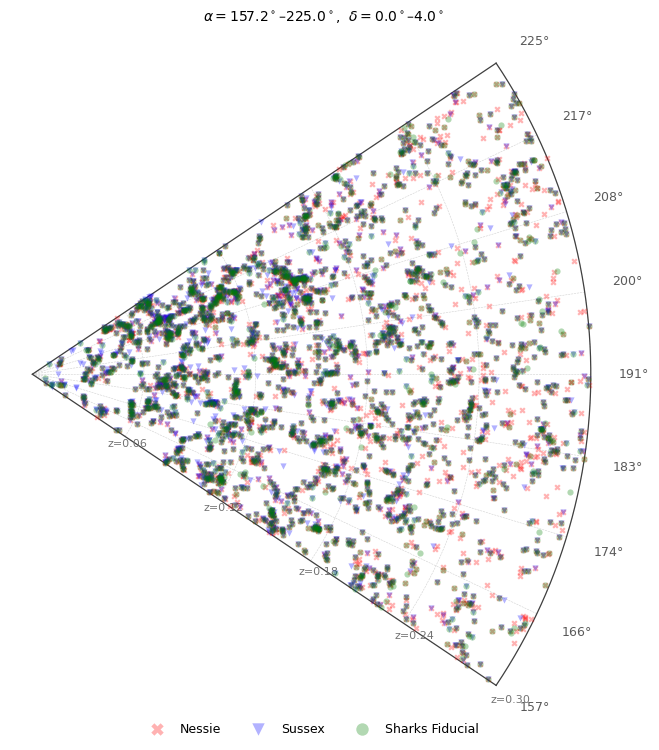

In [19]:
nessie_min_5 = nessie_groups_sharks[nessie_groups_sharks["nessie_multiplicity"] >= 5]
sussex_min_5 = sussex_groups_sharks[sussex_groups_sharks["sussex_multiplicity"] >= 5]
sharks_min_5 = sharks_groups[sharks_groups["n_group_fof"] >= 5]

fig, ax, cats = plot_single_region_wedge(
    catalogs=[nessie_min_5, sussex_min_5, sharks_min_5],
    column_specs=[
        {"ra": "nessie_iter_ra", "dec": "nessie_iter_dec", "z": "nessie_iter_redshift"},
        {"ra": "sussex_centre_ra", "dec": "sussex_centre_dec", "z": "sussex_centre_redshift"},
        {"ra": "ra_bcg", "dec": "dec_bcg", "z": "redshift_observed_bcg"},
    ],
    ra_min=157.25, ra_max=225.0,
    dec_min=0, dec_max=3.95,
    labels=["Nessie", "Sussex", "Sharks Fiducial"],
    colors=["Red", "Blue", "Green"],
    markers=["X", "v", "o"],
    figsize=(8, 8),
    size = 20, 
    alpha = 0.3
)
plt.savefig("../../plots/sharks_gama_wedge_overlay.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# Most likely issue is stellar masses. I should check that normalised histograms look the same between 
# GAMA and Sharks.
sharks.columns

Index(['ra', 'dec', 'galaxy_id', 'redshift_observed', 'redshift_cosmological',
       'mass_stellar_total', 'mass_virial_hosthalo', 'mass_virial_subhalo',
       'sfr_total', 'id_group_sky', 'mag_r_SDSS', 'group_id_truth', 'masked',
       'mag_r_VST', 'mag_Z_VISTA', 'mag_abs_Z_VISTA', 'mag_abs_r_VST',
       'mag_abs_r_SDSS', 'log_sSFR', 'is_red', 'DM', 'k-e corr',
       'stellar_mass', 'group_id_nessie', 'group_id_sussex'],
      dtype='object')

In [22]:
gama['stellar_mass']

0         7.807383e+10
1         4.010147e+11
2         5.244266e+10
3         4.716661e+10
4         2.231754e+11
              ...     
152231    3.960572e+10
152232    8.182755e+10
152233    3.691048e+09
152234    4.269652e+10
152235    5.567305e+10
Name: stellar_mass, Length: 152236, dtype: float32

In [23]:
sharks['mag_r_VST']

0         17.232548
1         19.637480
2         19.166838
3         19.637430
4         19.523787
            ...    
332033    18.100603
332034    19.490602
332035    19.178406
332036    18.501051
332037    19.538671
Name: mag_r_VST, Length: 332038, dtype: float32

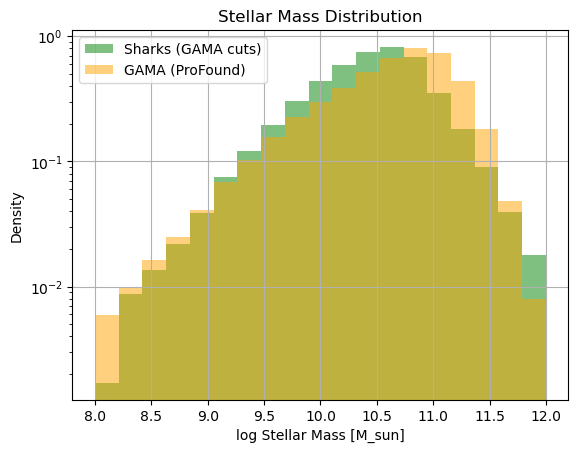

In [28]:
bins = np.linspace(8, 12, 20)
plt.hist(sharks['mass_stellar_total'], bins=bins, alpha=0.5, label='Sharks (GAMA cuts)', color='green', log= True, density=True)
plt.hist(np.log10(gama['stellar_mass']), bins=bins, alpha=0.5, label='GAMA (ProFound)', color='orange', log= True, density=True)
plt.legend()
plt.xlabel('log Stellar Mass [M_sun]')
plt.ylabel('Density')
plt.grid()
plt.title('Stellar Mass Distribution')
plt.savefig('../../plots/gama-sharks_stellar_mass_distribution.png')